# TAHAP 10 — Synthetic Dataset Generator for EduPath v2

Notebook ini menyusun *synthetic dataset generator* untuk project **EduPath Career Assistant v2**. Tahap ini melanjutkan output Tahap 09 berupa requirement redesign dan taxonomy: sekolah Indonesia, program studi PDDikti-style, RIASEC, Multiple Intelligences, VARK, Grit/Mindset, Career Alignment, rancangan dataset v2, dan rancangan scoring engine awal.

## Output Tahap 10

1. `student_profiles_synthetic_v2.csv`
2. `chat_history_synthetic_v2.csv`
3. `intent_dataset_synthetic_v2.csv`
4. `intent_dataset_v2_synthetic.csv` pada `data/processed/`
5. `profile_mapping_synthetic_v2.csv`
6. `initial_major_vs_recommendation_v2.csv`
7. `synthetic_data_quality_report_stage10.csv`
8. Visualisasi distribusi label untuk laporan UAS
9. Kesimpulan akademik otomatis dalam Markdown

## 1. Tujuan Synthetic Data Generator

Synthetic data generator dibuat untuk menghasilkan data latih dan data evaluasi awal yang terstruktur, konsisten dengan taxonomy v2, serta aman dari sisi privasi karena tidak menggunakan identitas siswa nyata.

Secara akademik, generator ini berfungsi untuk:

- memperbesar volume data agar pipeline NLP dan recommender dapat diuji secara lebih realistis;
- menyatukan sinyal profil siswa, taxonomy program studi, minat, gaya belajar, mindset, dan orientasi karier;
- membuat weak label awal untuk intent classification dan hybrid recommender;
- menyediakan laporan validasi kualitas data, distribusi label, dan coverage taxonomy.

Catatan batasan: dataset ini adalah data sintetis berbasis aturan, sehingga belum boleh diklaim mewakili populasi siswa Indonesia secara statistik. Validasi domain expert tetap diperlukan pada tahap berikutnya.

## 2. Import Library, Konfigurasi Path, dan Load Taxonomy Tahap 09

Cell berikut menyiapkan environment, membaca taxonomy Tahap 09, dan memuat konfigurasi scoring engine jika file `models/recommender_scoring_config_v2.json` tersedia.

In [1]:
from pathlib import Path
from datetime import datetime
import json
import random
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
rng = np.random.default_rng(RANDOM_SEED)

# Deteksi root project.
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.lower() == "notebooks" else CURRENT_DIR

TAXONOMY_DIR_CANDIDATES = [
    PROJECT_ROOT / "taxonomy",
    PROJECT_ROOT / "data" / "taxonomy",
]
MODEL_DIR = PROJECT_ROOT / "models"

SYNTHETIC_DIR = PROJECT_ROOT / "data" / "synthetic"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_STAGE10_DIR = PROJECT_ROOT / "reports" / "stage10"
FIGURE_STAGE10_DIR = PROJECT_ROOT / "reports" / "figures" / "stage10"

for folder in [SYNTHETIC_DIR, PROCESSED_DIR, REPORT_STAGE10_DIR, FIGURE_STAGE10_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Parameter dapat diturunkan saat uji coba awal.
N_STUDENTS = 12000
N_INTENT_UTTERANCES = 15000
N_CONVERSATIONS = 8000
TOP_N_RECOMMENDATION = 5

GENERATOR_VERSION = "stage10-v2.0"
GENERATED_AT = datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def resolve_taxonomy_file(filename: str) -> Path:
    for taxonomy_dir in TAXONOMY_DIR_CANDIDATES:
        path = taxonomy_dir / filename
        if path.exists():
            return path
    raise FileNotFoundError(
        f"File {filename} tidak ditemukan. Cek folder taxonomy/ atau data/taxonomy/."
    )


def read_taxonomy(filename: str) -> pd.DataFrame:
    path = resolve_taxonomy_file(filename)
    df = pd.read_csv(path)
    print(f"Loaded {filename}: {df.shape} | {path}")
    return df

school_taxonomy = read_taxonomy("school_taxonomy_v2.csv")
program_taxonomy = read_taxonomy("program_studi_taxonomy_pddikti_style_v2.csv")
riasec_taxonomy = read_taxonomy("riasec_taxonomy_v2.csv")
mi_taxonomy = read_taxonomy("multiple_intelligences_taxonomy_v2.csv")
vark_taxonomy = read_taxonomy("vark_taxonomy_v2.csv")
grit_mindset_taxonomy = read_taxonomy("grit_mindset_taxonomy_v2.csv")
career_alignment_taxonomy = read_taxonomy("career_alignment_taxonomy_v2.csv")

DEFAULT_SCORE_WEIGHTS = {
    "text_similarity": 0.25,
    "riasec_fit": 0.20,
    "multiple_intelligence_fit": 0.15,
    "school_background_fit": 0.10,
    "career_alignment_fit": 0.10,
    "academic_readiness": 0.10,
    "vark_fit": 0.05,
    "initial_choice_alignment": 0.05,
}

scoring_config_path = MODEL_DIR / "recommender_scoring_config_v2.json"
if scoring_config_path.exists():
    with open(scoring_config_path, "r", encoding="utf-8") as f:
        scoring_config = json.load(f)
    SCORE_WEIGHTS = scoring_config.get("score_components", DEFAULT_SCORE_WEIGHTS)
    print("\nScoring config loaded:", scoring_config_path)
else:
    scoring_config = {"score_components": DEFAULT_SCORE_WEIGHTS}
    SCORE_WEIGHTS = DEFAULT_SCORE_WEIGHTS
    print("\nScoring config tidak ditemukan. Menggunakan default weight.")

print("\nPROJECT_ROOT:", PROJECT_ROOT)
print("Generator:", GENERATOR_VERSION, "|", GENERATED_AT)
print("Score weights:", SCORE_WEIGHTS)

Loaded school_taxonomy_v2.csv: (22, 8) | D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\data\taxonomy\school_taxonomy_v2.csv
Loaded program_studi_taxonomy_pddikti_style_v2.csv: (35, 18) | D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\data\taxonomy\program_studi_taxonomy_pddikti_style_v2.csv
Loaded riasec_taxonomy_v2.csv: (6, 5) | D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\data\taxonomy\riasec_taxonomy_v2.csv
Loaded multiple_intelligences_taxonomy_v2.csv: (8, 5) | D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\data\taxonomy\multiple_intelligences_taxonomy_v2.csv
Loaded vark_taxonomy_v2.csv: (4, 5) | D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\data\taxonomy\vark_taxonomy_v2.csv
Loaded grit_mindset_taxonomy_v2.csv: (6, 5) | D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\data\taxonomy\grit_mindset_t

## 3. Validasi Kolom Wajib Taxonomy

Validasi ini memastikan file taxonomy memiliki kolom inti yang dibutuhkan generator. Jika ada kolom yang hilang, proses dihentikan agar tidak menghasilkan dataset yang salah struktur.

In [2]:
required_columns = {
    "school_taxonomy": [
        "school_taxonomy_id", "school_type", "school_group", "school_major_detail",
        "subject_context", "recommended_higher_education_area", "keywords",
    ],
    "program_taxonomy": [
        "program_id", "program_name", "jenjang", "rumpun_ilmu", "bidang_keilmuan",
        "riasec_primary", "riasec_secondary", "mi_primary", "vark_preferred",
        "career_alignment", "math_level", "coding_level", "communication_level",
        "design_level", "school_fit", "career_examples", "keywords",
    ],
    "riasec_taxonomy": ["riasec_name", "keyword_signals"],
    "mi_taxonomy": ["mi_name", "keyword_signals"],
    "vark_taxonomy": ["vark_name", "keyword_signals"],
    "career_alignment_taxonomy": ["career_alignment_name", "keyword_signals"],
}

actual_dfs = {
    "school_taxonomy": school_taxonomy,
    "program_taxonomy": program_taxonomy,
    "riasec_taxonomy": riasec_taxonomy,
    "mi_taxonomy": mi_taxonomy,
    "vark_taxonomy": vark_taxonomy,
    "career_alignment_taxonomy": career_alignment_taxonomy,
}

for name, columns in required_columns.items():
    missing = [col for col in columns if col not in actual_dfs[name].columns]
    if missing:
        raise ValueError(f"Kolom wajib hilang pada {name}: {missing}")
    print(f"OK - {name}: seluruh kolom wajib tersedia.")

print("\nPreview school_taxonomy:")
display(school_taxonomy.head())

print("\nPreview program_taxonomy:")
display(program_taxonomy.head())

OK - school_taxonomy: seluruh kolom wajib tersedia.
OK - program_taxonomy: seluruh kolom wajib tersedia.
OK - riasec_taxonomy: seluruh kolom wajib tersedia.
OK - mi_taxonomy: seluruh kolom wajib tersedia.
OK - vark_taxonomy: seluruh kolom wajib tersedia.
OK - career_alignment_taxonomy: seluruh kolom wajib tersedia.

Preview school_taxonomy:


,school_taxonomy_id,school_type,school_group,school_major_detail,subject_context,recommended_higher_education_area,keywords,notes
0,SCH-SMA-001,SMA,Umum,MIPA/IPA,"Matematika, Fisika, Kimia, Biologi","Sains, Teknik, Kesehatan, Komputasi",Matematika|Fisika|Kimia|Biologi|Informatika,SMA jalur lama atau sekolah yang masih memakai...
1,SCH-SMA-002,SMA,Umum,IPS/Soshum,"Ekonomi, Sosiologi, Geografi, Sejarah","Bisnis, Hukum, Komunikasi, Psikologi, Administ...",Ekonomi|Sosiologi|Geografi|Sejarah,SMA jalur lama atau preferensi mapel sosial-hu...
2,SCH-SMA-003,SMA,Umum,Bahasa dan Budaya,"Bahasa Indonesia, Bahasa Inggris, Bahasa asing...","Bahasa, Komunikasi, Sastra, Hubungan Internasi...",Bahasa Indonesia|Bahasa Inggris|Sastra|Public ...,SMA jalur lama atau preferensi bahasa
3,SCH-SMA-004,SMA,Umum,Seni/Kreatif,"Seni Budaya, Desain, Musik, Konten Kreatif","DKV, Desain Produk, Seni, Film, Musik",Seni|Desain|Musik|Kreatif|Konten,Kelompok minat kreatif
4,SCH-SMA-005,SMA,Umum,Pilihan Campuran Kurikulum Merdeka,"Kombinasi mapel sains, sosial, bahasa, atau seni",Lintas rumpun sesuai kombinasi mapel,Mapel Pilihan|Fase F|Campuran,Untuk siswa kelas XI/XII yang memilih mapel fl...



Preview program_taxonomy:


,program_id,program_name,jenjang,rumpun_ilmu,bidang_keilmuan,riasec_primary,riasec_secondary,mi_primary,vark_preferred,career_alignment,math_level,coding_level,communication_level,design_level,school_fit,career_examples,keywords,pddikti_reference_status
0,PRG2-001,Teknik Informatika,S1,Komputer/Informatika,Teknologi,Investigative,Realistic,Logis-Matematis,Kinesthetic,Praktikal,tinggi,tinggi,sedang,rendah,SMA MIPA; SMK RPL/TKJ/SIJA,Software Engineer; Backend Developer; AI Engineer,coding|algoritma|software|komputer|aplikasi,prototype_pddikti_style
1,PRG2-002,Sistem Informasi,S1,Komputer/Informatika,Teknologi-Bisnis,Conventional,Enterprising,Logis-Matematis,Reading/Writing,Eksekutif,sedang,sedang,tinggi,rendah,SMA IPS/MIPA; SMK RPL/TKJ/Bisnis,Business Analyst; System Analyst; ERP Consultant,sistem informasi|bisnis|analisis sistem|erp|pr...,prototype_pddikti_style
2,PRG2-003,Sains Data,S1,Komputer/Informatika,Data dan AI,Investigative,Conventional,Logis-Matematis,Visual,Akademik,sangat tinggi,tinggi,sedang,rendah,SMA MIPA; SMK RPL/SIJA,Data Analyst; Data Scientist; ML Engineer,data science|statistika|machine learning|dashb...,prototype_pddikti_style
3,PRG2-004,Teknologi Informasi,S1,Komputer/Informatika,Infrastruktur dan Sistem,Realistic,Investigative,Logis-Matematis,Kinesthetic,Praktikal,tinggi,tinggi,sedang,rendah,SMA MIPA; SMK TKJ/SIJA,IT Infrastructure Engineer; Cloud Engineer; Ne...,jaringan|server|cloud|infrastruktur|cybersecurity,prototype_pddikti_style
4,PRG2-005,Bisnis Digital,S1,Bisnis dan Manajemen,Teknologi-Bisnis,Enterprising,Conventional,Interpersonal,Visual,Eksekutif,sedang,sedang,tinggi,sedang,SMA IPS; SMK Bisnis Digital/Pemasaran,Digital Business Analyst; Product Associate; D...,bisnis digital|ecommerce|startup|produk digita...,prototype_pddikti_style


## 4. Utility Function dan Rule-Based Scoring Engine

Cell ini berisi fungsi bantu untuk text cleaning, keyword parsing, ordinal level mapping, serta scoring engine awal. Scoring engine digunakan untuk menghasilkan label rekomendasi sintetis berbasis kombinasi text similarity, RIASEC, Multiple Intelligences, school background, career alignment, academic readiness, VARK, dan initial choice alignment.

In [3]:
LEVEL_MAP = {
    "rendah": 1,
    "sedang": 2,
    "tinggi": 3,
    "sangat tinggi": 4,
    "low": 1,
    "medium": 2,
    "high": 3,
    "very high": 4,
}

STOPWORDS_SIMPLE = {
    "dan", "atau", "yang", "di", "ke", "dari", "untuk", "dengan", "pada",
    "saya", "aku", "abdi", "urang", "ingin", "mau", "pengin", "jurusan",
    "program", "studi", "kuliah", "cocok", "apa", "ya", "nya", "itu", "ini",
}


def clean_text(text) -> str:
    if pd.isna(text):
        return ""
    text = str(text).lower().replace("/", " ").replace("-", " ")
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def split_signals(value) -> list:
    if pd.isna(value):
        return []
    parts = re.split(r"[|;,/]", str(value))
    return [part.strip() for part in parts if part and part.strip()]


def tokenize_signals(value) -> set:
    cleaned = clean_text(value)
    return {tok for tok in cleaned.split() if tok not in STOPWORDS_SIMPLE and len(tok) > 1}


def choose_one(values, default=None):
    values = [v for v in values if pd.notna(v) and str(v).strip()]
    return random.choice(values) if values else default


def choose_many(values, min_k=1, max_k=3) -> list:
    values = list(dict.fromkeys([str(v).strip() for v in values if pd.notna(v) and str(v).strip()]))
    if not values:
        return []
    k = random.randint(min_k, min(max_k, len(values)))
    return random.sample(values, k)


def level_to_num(value) -> int:
    return LEVEL_MAP.get(clean_text(value), 2)


def pipe_join(values) -> str:
    values = [str(v).strip() for v in values if pd.notna(v) and str(v).strip()]
    return "|".join(list(dict.fromkeys(values)))


def weighted_choice_index(weights) -> int:
    weights = np.array(weights, dtype=float)
    if weights.sum() <= 0:
        weights = np.ones(len(weights))
    return int(rng.choice(np.arange(len(weights)), p=weights / weights.sum()))


def keyword_overlap_score(profile_text: str, program_text: str) -> float:
    profile_tokens = tokenize_signals(profile_text)
    program_tokens = tokenize_signals(program_text)
    if not profile_tokens or not program_tokens:
        return 0.0
    overlap = profile_tokens.intersection(program_tokens)
    denominator = max(1, min(len(program_tokens), 8))
    return round(min(1.0, len(overlap) / denominator), 3)

# Precompute teks program untuk matching.
program_taxonomy = program_taxonomy.copy()
program_taxonomy["program_text_for_matching"] = (
    program_taxonomy["program_name"].astype(str) + " " +
    program_taxonomy["bidang_keilmuan"].astype(str) + " " +
    program_taxonomy["school_fit"].astype(str) + " " +
    program_taxonomy["career_examples"].astype(str) + " " +
    program_taxonomy["keywords"].astype(str)
)


def riasec_fit(profile: dict, program: pd.Series) -> float:
    p_primary = profile.get("riasec_primary", "")
    p_secondary = profile.get("riasec_secondary", "")
    if p_primary == program.get("riasec_primary"):
        return 1.0
    if p_primary == program.get("riasec_secondary"):
        return 0.8
    if p_secondary == program.get("riasec_primary"):
        return 0.7
    if p_secondary == program.get("riasec_secondary"):
        return 0.6
    return 0.3


def multiple_intelligence_fit(profile: dict, program: pd.Series) -> float:
    return 1.0 if profile.get("mi_primary", "") == program.get("mi_primary", "") else 0.45


def school_background_fit(profile: dict, program: pd.Series) -> float:
    school_text = clean_text(
        f"{profile.get('school_type', '')} {profile.get('school_major_detail', '')} "
        f"{profile.get('school_keywords', '')} {profile.get('subject_strengths', '')}"
    )
    school_fit_text = clean_text(program.get("school_fit", ""))
    if not school_text or not school_fit_text:
        return 0.4
    overlap = tokenize_signals(school_text).intersection(tokenize_signals(school_fit_text))
    if len(overlap) >= 2:
        return 1.0
    if len(overlap) == 1:
        return 0.75
    if clean_text(profile.get("school_type", "")) in school_fit_text:
        return 0.65
    return 0.35


def career_alignment_fit(profile: dict, program: pd.Series) -> float:
    return 1.0 if profile.get("career_alignment", "") == program.get("career_alignment", "") else 0.45


def academic_readiness(profile: dict, program: pd.Series) -> float:
    pairs = [
        ("academic_math_level", "math_level"),
        ("academic_coding_level", "coding_level"),
        ("academic_communication_level", "communication_level"),
        ("academic_design_level", "design_level"),
    ]
    scores = []
    for student_col, program_col in pairs:
        diff = level_to_num(profile.get(student_col, "sedang")) - level_to_num(program.get(program_col, "sedang"))
        scores.append(1.0 if diff >= 0 else 0.7 if diff == -1 else 0.4)
    return round(float(np.mean(scores)), 3)


def vark_fit(profile: dict, program: pd.Series) -> float:
    return 1.0 if profile.get("vark_primary", "") == program.get("vark_preferred", "") else 0.5


def initial_choice_alignment(profile: dict, program: pd.Series) -> float:
    initial_choice = clean_text(profile.get("initial_choice_program", ""))
    program_name = clean_text(program.get("program_name", ""))
    if not initial_choice or initial_choice in {"belum yakin", "belum tahu", "bingung"}:
        return 0.5
    if initial_choice == program_name:
        return 1.0
    if initial_choice in program_name or program_name in initial_choice:
        return 0.9
    if clean_text(profile.get("initial_choice_rumpun", "")) == clean_text(program.get("rumpun_ilmu", "")):
        return 0.65
    return 0.3


def compute_program_scores(profile: dict, programs_df: pd.DataFrame, top_n: int = 5) -> pd.DataFrame:
    profile_text = " ".join([
        str(profile.get("subject_strengths", "")),
        str(profile.get("hobby_signals", "")),
        str(profile.get("career_goal", "")),
        str(profile.get("profile_summary", "")),
        str(profile.get("initial_choice_program", "")),
    ])
    rows = []
    for _, program in programs_df.iterrows():
        components = {
            "text_similarity": keyword_overlap_score(profile_text, program.get("program_text_for_matching", "")),
            "riasec_fit": riasec_fit(profile, program),
            "multiple_intelligence_fit": multiple_intelligence_fit(profile, program),
            "school_background_fit": school_background_fit(profile, program),
            "career_alignment_fit": career_alignment_fit(profile, program),
            "academic_readiness": academic_readiness(profile, program),
            "vark_fit": vark_fit(profile, program),
            "initial_choice_alignment": initial_choice_alignment(profile, program),
        }
        final_score = sum(components[k] * SCORE_WEIGHTS.get(k, 0) for k in components)
        rows.append({
            "program_id": program["program_id"],
            "program_name": program["program_name"],
            "rumpun_ilmu": program["rumpun_ilmu"],
            "bidang_keilmuan": program["bidang_keilmuan"],
            "career_examples": program["career_examples"],
            **components,
            "final_score": round(final_score, 3),
        })
    scores_df = pd.DataFrame(rows).sort_values("final_score", ascending=False).reset_index(drop=True)
    scores_df["recommendation_rank"] = np.arange(1, len(scores_df) + 1)
    return scores_df.head(top_n)

print("Utility dan scoring engine siap digunakan.")

Utility dan scoring engine siap digunakan.


## 5. Generator Profil Siswa SMA/MA/SMK/MAK

Profil siswa dibuat dari kombinasi taxonomy sekolah dan taxonomy program studi. Sebagian atribut dibuat selaras dengan program seed, sedangkan sebagian kecil diberi variasi/noise agar data tidak terlalu sempurna.

In [4]:
RIASEC_NAMES = program_taxonomy["riasec_primary"].dropna().unique().tolist()
MI_NAMES = mi_taxonomy["mi_name"].dropna().unique().tolist()
VARK_NAMES = vark_taxonomy["vark_name"].dropna().unique().tolist()
CAREER_ALIGNMENTS = career_alignment_taxonomy["career_alignment_name"].dropna().unique().tolist()

GRIT_LEVELS = ["Low", "Medium", "High"]
GRIT_PROBS = [0.15, 0.60, 0.25]
MINDSET_TYPES = ["Growth", "Mixed", "Fixed"]
MINDSET_PROBS = [0.55, 0.35, 0.10]

LANGUAGE_VARIANTS = ["id_formal", "id_nonformal", "jawa_umum", "sunda_umum", "mixed"]
LANGUAGE_PROBS = [0.42, 0.36, 0.08, 0.08, 0.06]


def compatible_program_candidates(school_row: pd.Series, programs_df: pd.DataFrame) -> pd.DataFrame:
    school_signal = clean_text(
        f"{school_row.get('school_type', '')} {school_row.get('school_major_detail', '')} {school_row.get('keywords', '')}"
    )
    school_tokens = tokenize_signals(school_signal)
    scores = []
    for _, program in programs_df.iterrows():
        overlap = len(school_tokens.intersection(tokenize_signals(program.get("school_fit", ""))))
        scores.append(overlap)
    temp = programs_df.copy()
    temp["compatibility_seed_score"] = scores
    compatible = temp[temp["compatibility_seed_score"] > 0].copy()
    return compatible if not compatible.empty else temp


def noisy_level(base_level: str, noise_probability: float = 0.25) -> str:
    levels = ["rendah", "sedang", "tinggi", "sangat tinggi"]
    base_num = level_to_num(base_level)
    if random.random() > noise_probability:
        return base_level
    new_num = int(np.clip(base_num + random.choice([-1, 1]), 1, 4))
    return levels[new_num - 1]


def generate_single_student(index: int) -> dict:
    school_row = school_taxonomy.sample(n=1, random_state=RANDOM_SEED + index).iloc[0]
    candidates = compatible_program_candidates(school_row, program_taxonomy)
    weights = candidates.get("compatibility_seed_score", pd.Series([1] * len(candidates))).values + 1
    target_program = candidates.iloc[weighted_choice_index(weights)]

    riasec_primary = target_program["riasec_primary"] if random.random() < 0.82 else choose_one(RIASEC_NAMES)
    riasec_secondary = target_program["riasec_secondary"] if random.random() < 0.75 else choose_one(RIASEC_NAMES)
    if riasec_secondary == riasec_primary:
        riasec_secondary = choose_one([r for r in RIASEC_NAMES if r != riasec_primary], default=riasec_secondary)

    mi_primary = target_program["mi_primary"] if random.random() < 0.80 else choose_one(MI_NAMES)
    vark_primary = target_program["vark_preferred"] if random.random() < 0.70 else choose_one(VARK_NAMES)
    career_alignment = target_program["career_alignment"] if random.random() < 0.78 else choose_one(CAREER_ALIGNMENTS)

    school_keywords = split_signals(school_row.get("keywords", ""))
    program_keywords = split_signals(target_program.get("keywords", ""))

    riasec_signal = riasec_taxonomy.loc[riasec_taxonomy["riasec_name"].eq(riasec_primary), "keyword_signals"]
    riasec_keywords = split_signals(riasec_signal.iloc[0]) if len(riasec_signal) else []

    mi_signal = mi_taxonomy.loc[mi_taxonomy["mi_name"].eq(mi_primary), "keyword_signals"]
    mi_keywords = split_signals(mi_signal.iloc[0]) if len(mi_signal) else []

    career_goal = choose_one(split_signals(str(target_program.get("career_examples", "")).replace(";", "|")), default="karier profesional")
    subject_strengths = pipe_join(choose_many(school_keywords + program_keywords, min_k=2, max_k=4))
    hobby_signals = pipe_join(choose_many(program_keywords + riasec_keywords + mi_keywords, min_k=2, max_k=5))

    initial_choice_mode = random.random()
    if initial_choice_mode < 0.62:
        initial_choice_program = target_program["program_name"]
        initial_choice_rumpun = target_program["rumpun_ilmu"]
    elif initial_choice_mode < 0.88:
        random_program = program_taxonomy.sample(n=1).iloc[0]
        initial_choice_program = random_program["program_name"]
        initial_choice_rumpun = random_program["rumpun_ilmu"]
    else:
        initial_choice_program = "Belum yakin"
        initial_choice_rumpun = "Belum yakin"

    profile = {
        "student_id": f"STU-{index:06d}",
        "school_taxonomy_id": school_row["school_taxonomy_id"],
        "school_type": school_row["school_type"],
        "school_group": school_row["school_group"],
        "school_major_detail": school_row["school_major_detail"],
        "school_keywords": school_row.get("keywords", ""),
        "grade_level": "XII",
        "subject_strengths": subject_strengths,
        "hobby_signals": hobby_signals,
        "riasec_primary": riasec_primary,
        "riasec_secondary": riasec_secondary,
        "mi_primary": mi_primary,
        "vark_primary": vark_primary,
        "grit_level": rng.choice(GRIT_LEVELS, p=GRIT_PROBS),
        "mindset_type": rng.choice(MINDSET_TYPES, p=MINDSET_PROBS),
        "career_alignment": career_alignment,
        "career_goal": career_goal,
        "initial_choice_program": initial_choice_program,
        "initial_choice_rumpun": initial_choice_rumpun,
        "target_seed_program_id": target_program["program_id"],
        "target_seed_program_name": target_program["program_name"],
        "academic_math_level": noisy_level(target_program["math_level"]),
        "academic_coding_level": noisy_level(target_program["coding_level"]),
        "academic_communication_level": noisy_level(target_program["communication_level"]),
        "academic_design_level": noisy_level(target_program["design_level"]),
        "synthetic_source": "taxonomy_rule_based_generator",
        "generator_version": GENERATOR_VERSION,
    }

    profile["profile_summary"] = (
        f"Siswa {profile['school_type']} jurusan/konteks {profile['school_major_detail']} "
        f"kuat pada {profile['subject_strengths']} dan tertarik pada {profile['hobby_signals']}. "
        f"Orientasi RIASEC {profile['riasec_primary']} dengan kecerdasan {profile['mi_primary']}."
    )

    top_scores = compute_program_scores(profile, program_taxonomy, top_n=TOP_N_RECOMMENDATION)
    profile["expected_top_programs"] = pipe_join(top_scores["program_name"].tolist())
    profile["expected_top_program_ids"] = pipe_join(top_scores["program_id"].tolist())
    profile["expected_top1_program"] = top_scores.iloc[0]["program_name"]
    profile["expected_top1_program_id"] = top_scores.iloc[0]["program_id"]
    profile["expected_top1_score"] = top_scores.iloc[0]["final_score"]
    return profile

student_profiles_df = pd.DataFrame([generate_single_student(i) for i in range(1, N_STUDENTS + 1)])
print("student_profiles_df:", student_profiles_df.shape)
display(student_profiles_df.head())

student_profiles_df: (12000, 33)


,student_id,school_taxonomy_id,school_type,school_group,school_major_detail,school_keywords,grade_level,subject_strengths,hobby_signals,riasec_primary,...,academic_communication_level,academic_design_level,synthetic_source,generator_version,profile_summary,expected_top_programs,expected_top_program_ids,expected_top1_program,expected_top1_program_id,expected_top1_score
0,STU-000001,SCH-MAK-001,MAK,Madrasah Vokasi,MAK Teknologi/Bisnis/Kesehatan/Kreatif,MAK|Vokasi|Keagamaan|Konsentrasi,XII,keadilan|Vokasi|hukum|Konsentrasi,hukum|argumentasi,Conventional,...,tinggi,rendah,taxonomy_rule_based_generator,stage10-v2.0,Siswa MAK jurusan/konteks MAK Teknologi/Bisnis...,Ilmu Hukum|Sistem Informasi|Manajemen|Teknik I...,PRG2-022|PRG2-002|PRG2-026|PRG2-007|PRG2-027,Ilmu Hukum,PRG2-022,0.913
1,STU-000002,SCH-SMK-009,SMK,Vokasi,Farmasi Klinis dan Komunitas,Farmasi|Obat|Kimia|Kesehatan,XII,Kimia|Kesehatan|grammar,speaking|grammar|menulis|komunikasi,Social,...,sangat tinggi,sedang,taxonomy_rule_based_generator,stage10-v2.0,Siswa SMK jurusan/konteks Farmasi Klinis dan K...,Pendidikan Bahasa Inggris|Kesehatan Masyarakat...,PRG2-025|PRG2-018|PRG2-017|PRG2-024|PRG2-021,Pendidikan Bahasa Inggris,PRG2-025,0.919
2,STU-000003,SCH-SMK-005,SMK,Vokasi,Akuntansi dan Keuangan Lembaga,Akuntansi|Keuangan|Pajak|Excel|Administrasi,XII,Keuangan|Akuntansi,negosiasi|audit|memimpin,Enterprising,...,sedang,sedang,taxonomy_rule_based_generator,stage10-v2.0,Siswa SMK jurusan/konteks Akuntansi dan Keuang...,Akuntansi|Agribisnis|Manajemen|Statistika|Tekn...,PRG2-027|PRG2-032|PRG2-026|PRG2-012|PRG2-001,Akuntansi,PRG2-027,0.803
3,STU-000004,SCH-SMA-002,SMA,Umum,IPS/Soshum,Ekonomi|Sosiologi|Geografi|Sejarah,XII,Geografi|Sejarah,anak|pasien|edukasi|visual|gambar,Social,...,tinggi,sedang,taxonomy_rule_based_generator,stage10-v2.0,Siswa SMA jurusan/konteks IPS/Soshum kuat pada...,Kesehatan Masyarakat|Psikologi|Pendidikan Baha...,PRG2-018|PRG2-020|PRG2-025|PRG2-017|PRG2-019,Kesehatan Masyarakat,PRG2-018,0.768
4,STU-000005,SCH-SMA-005,SMA,Umum,Pilihan Campuran Kurikulum Merdeka,Mapel Pilihan|Fase F|Campuran,XII,kebijakan|Campuran|layanan publik|administrasi...,edukasi|komunitas|membantu|lingkungan|kebijakan,Social,...,tinggi,rendah,taxonomy_rule_based_generator,stage10-v2.0,Siswa SMA jurusan/konteks Pilihan Campuran Kur...,Administrasi Publik|Sistem Informasi|Kesehatan...,PRG2-023|PRG2-002|PRG2-018|PRG2-019|PRG2-022,Administrasi Publik,PRG2-023,0.795


## 6. Generator Variasi History Chat Siswa Kelas XII

History chat dibuat dalam bentuk multi-turn conversation berisi pesan user dan bot. Pesan user diberi intent label agar dapat dimanfaatkan sebagai sumber data intent classification.


In [5]:
INTENT_LABELS = [
    "sapaan", "rekomendasi_prodi", "roadmap_belajar", "prospek_karier",
    "skill_awal", "info_program_studi", "klarifikasi_minat",
    "bandingkan_pilihan_awal", "fallback",
]
INTENT_PROBS = [0.05, 0.26, 0.14, 0.12, 0.11, 0.09, 0.10, 0.10, 0.03]


def get_interest_phrase(profile: dict) -> str:
    signals = split_signals(profile.get("hobby_signals", "")) + split_signals(profile.get("subject_strengths", ""))
    selected = choose_many(signals, min_k=1, max_k=2)
    return " dan ".join(selected) if selected else "belajar hal baru"


def generate_user_message(profile: dict, intent_label: str, language_variant: str) -> str:
    major = profile.get("school_major_detail", "sekolah")
    school_type = profile.get("school_type", "SMA")
    interest = get_interest_phrase(profile)
    initial_choice = profile.get("initial_choice_program", "Belum yakin")
    top1 = profile.get("expected_top1_program", "program studi yang sesuai")

    templates = {
        "id_formal": {
            "sapaan": ["Halo, saya ingin konsultasi tentang pilihan program studi.", "Selamat pagi, saya butuh arahan memilih jurusan kuliah."],
            "rekomendasi_prodi": ["Saya siswa {school_type} jurusan {major}. Saya tertarik pada {interest}. Program studi apa yang sesuai?", "Saya menyukai {interest}. Mohon rekomendasi program studi yang relevan."],
            "roadmap_belajar": ["Jika saya memilih {top1}, roadmap belajar awal apa yang perlu saya siapkan?", "Mohon dibuatkan roadmap belajar 3 sampai 6 bulan untuk {top1}."],
            "prospek_karier": ["Bagaimana prospek karier dari program studi {top1}?", "Karier apa saja yang dapat ditempuh dari {top1}?"],
            "skill_awal": ["Skill awal apa yang sebaiknya saya kuasai sebelum mengambil {top1}?", "Kompetensi dasar apa yang perlu saya pelajari dari sekarang?"],
            "info_program_studi": ["Tolong jelaskan gambaran umum program studi {top1}.", "Apa saja yang biasanya dipelajari di {top1}?"],
            "klarifikasi_minat": ["Saya masih bingung dengan minat saya, tetapi saya cukup suka {interest}. Bagaimana cara memetakannya?", "Saya belum yakin minat utama saya. Apakah profil saya bisa dianalisis dari mata pelajaran dan hobi?"],
            "bandingkan_pilihan_awal": ["Saya awalnya ingin memilih {initial_choice}. Apakah pilihan itu selaras dengan profil saya?", "Tolong bandingkan pilihan awal saya yaitu {initial_choice} dengan rekomendasi sistem."],
            "fallback": ["Apakah chatbot ini bisa memesan tiket konser?", "Saya ingin bertanya tentang jadwal pertandingan bola malam ini."],
        },
        "id_nonformal": {
            "sapaan": ["Halo kak, aku mau tanya soal jurusan kuliah.", "Kak, boleh bantu aku cari jurusan yang cocok?"],
            "rekomendasi_prodi": ["Aku anak {school_type} jurusan {major}, suka {interest}. Cocoknya kuliah apa ya?", "Aku lumayan suka {interest}. Menurut sistem, prodi yang pas buat aku apa?"],
            "roadmap_belajar": ["Kalau aku ambil {top1}, belajar dari mana dulu ya?", "Bikinin roadmap singkat buat persiapan masuk {top1}."],
            "prospek_karier": ["Prospek kerja {top1} itu jadi apa aja ya?", "Lulusan {top1} biasanya bisa kerja sebagai apa?"],
            "skill_awal": ["Skill awal buat masuk {top1} apa aja kak?", "Aku harus belajar apa dulu biar siap masuk {top1}?"],
            "info_program_studi": ["{top1} itu belajar apa aja sih?", "Jelasin singkat tentang prodi {top1}."],
            "klarifikasi_minat": ["Aku masih bingung minatku apa, tapi suka {interest}. Bisa dibantu arahin?", "Aku belum yakin passion-ku, gimana cara nentuin jurusan?"],
            "bandingkan_pilihan_awal": ["Awalnya aku pengin {initial_choice}. Itu cocok nggak sama profilku?", "Bandingin {initial_choice} sama rekomendasi yang lebih cocok buat aku."],
            "fallback": ["Kak, rekomendasi HP gaming murah dong.", "Aku mau tanya resep makanan yang gampang dibuat."],
        },
        "jawa_umum": {
            "sapaan": ["Halo kak, aku arep takon soal jurusan kuliah.", "Kak, aku butuh arahan milih jurusan kuliah."],
            "rekomendasi_prodi": ["Aku siswa {school_type} jurusan {major}, seneng {interest}. Jurusan kuliah sing pas apa ya?", "Aku seneng {interest}, kira-kira prodi sing cocok kanggo aku apa?"],
            "roadmap_belajar": ["Yen aku milih {top1}, kudu sinau saka ngendi dhisik?", "Tulung gawekke roadmap belajar kanggo mlebu {top1}."],
            "prospek_karier": ["Prospek kerja saka {top1} kuwi apa wae?", "Lulusan {top1} biasane iso kerja dadi apa?"],
            "skill_awal": ["Skill awal kanggo {top1} apa wae sing kudu tak sinau?", "Aku kudu nyiapke kemampuan apa yen arep mlebu {top1}?"],
            "info_program_studi": ["{top1} kuwi sinau bab apa wae?", "Jelaske ringkes babagan prodi {top1}."],
            "klarifikasi_minat": ["Aku isih bingung minatku, nanging seneng {interest}. Iso dibantu?", "Aku durung yakin passion-ku, kepiye cara milih jurusan?"],
            "bandingkan_pilihan_awal": ["Awale aku kepengin {initial_choice}. Kuwi cocok ora karo profilku?", "Tulung bandingke {initial_choice} karo rekomendasi sistem."],
            "fallback": ["Kak, iso takon jadwal konser ora?", "Aku pengin ngerti rekomendasi game anyar."],
        },
        "sunda_umum": {
            "sapaan": ["Halo kak, abdi bade naros perkawis jurusan kuliah.", "Kak, tiasa bantos abdi milih jurusan kuliah?"],
            "rekomendasi_prodi": ["Abdi siswa {school_type} jurusan {major}, resep {interest}. Jurusan kuliah nu cocok naon?", "Abdi resep {interest}, kira-kira prodi anu pas kanggo abdi naon?"],
            "roadmap_belajar": ["Upami abdi milih {top1}, kedah diajar ti mana heula?", "Punten damelkeun roadmap belajar kanggo persiapan {top1}."],
            "prospek_karier": ["Prospek karier tina {top1} naon wae?", "Lulusan {top1} biasana tiasa damel janten naon?"],
            "skill_awal": ["Skill awal kanggo {top1} naon wae anu kedah disiapkeun?", "Abdi kedah diajar naon heula supados siap lebet {top1}?"],
            "info_program_studi": ["{top1} teh diajar naon wae?", "Punten jelaskeun ringkes ngeunaan prodi {top1}."],
            "klarifikasi_minat": ["Abdi masih bingung minat, tapi resep {interest}. Tiasa dibantos arahanna?", "Abdi teu acan yakin passion, kumaha cara milih jurusan?"],
            "bandingkan_pilihan_awal": ["Awalna abdi hoyong {initial_choice}. Eta cocog teu sareng profil abdi?", "Punten bandingkeun {initial_choice} sareng rekomendasi sistem."],
            "fallback": ["Kak, tiasa nyarankeun tempat liburan?", "Abdi bade naros perkawis jadwal konser."],
        },
        "mixed": {
            "sapaan": ["Halo kak, aku mau konsultasi jurusan kuliah nih.", "Hi kak, boleh bantu mapping minat dan prodi?"],
            "rekomendasi_prodi": ["Aku siswa {school_type} {major}, interest-ku di {interest}. Prodi yang match apa ya?", "Saya suka {interest}, major S1 yang paling cocok apa?"],
            "roadmap_belajar": ["Kalau targetku {top1}, learning roadmap awalnya gimana?", "Bantu susun roadmap basic buat masuk {top1} ya kak."],
            "prospek_karier": ["Career path dari {top1} apa saja kak?", "Kalau lulusan {top1}, peluang kariernya seperti apa?"],
            "skill_awal": ["Basic skill yang perlu dipelajari untuk {top1} apa aja?", "Aku perlu upgrade skill apa sebelum masuk {top1}?"],
            "info_program_studi": ["Explain singkat tentang prodi {top1} dong.", "Overview {top1} itu seperti apa?"],
            "klarifikasi_minat": ["Aku masih confuse soal passion, tapi interest di {interest}. Bisa dibantu mapping?", "Belum yakin minat utama, need guidance buat pilih jurusan."],
            "bandingkan_pilihan_awal": ["Initial choice aku {initial_choice}. Itu align nggak sama profile-ku?", "Compare {initial_choice} dengan rekomendasi sistem dong."],
            "fallback": ["Rekomendasi laptop gaming dong kak.", "Bisa bantu cari tempat nongkrong?"],
        },
    }
    selected = random.choice(templates.get(language_variant, templates["id_formal"])[intent_label])
    return selected.format(school_type=school_type, major=major, interest=interest, initial_choice=initial_choice, top1=top1)


def generate_bot_message(profile: dict, previous_intent: str) -> str:
    top_programs = split_signals(profile.get("expected_top_programs", ""))[:3]
    top_programs_text = ", ".join(top_programs) if top_programs else "beberapa program studi yang relevan"
    top1 = profile.get("expected_top1_program", "program studi prioritas")
    templates = {
        "sapaan": "Halo, saya akan membantu memetakan minat, profil sekolah, dan rekomendasi program studi secara awal.",
        "rekomendasi_prodi": f"Berdasarkan profil awal, rekomendasi sementara adalah {top_programs_text}. Hasil ini perlu divalidasi lagi dengan guru BK atau konselor.",
        "roadmap_belajar": f"Untuk persiapan {top1}, mulai dari penguatan konsep dasar, latihan proyek kecil, lalu susun portofolio sederhana.",
        "prospek_karier": f"Program {top1} memiliki beberapa prospek yang dapat dieksplorasi sesuai minat dan kompetensi siswa.",
        "skill_awal": f"Skill awal untuk {top1} dapat dimulai dari literasi dasar bidang, latihan praktik, dan kebiasaan belajar terstruktur.",
        "info_program_studi": f"{top1} adalah salah satu program yang relevan dengan sinyal minat dan profil akademik siswa.",
        "klarifikasi_minat": "Kita bisa mulai dari mata pelajaran favorit, aktivitas yang paling disukai, gaya belajar, dan bayangan karier.",
        "bandingkan_pilihan_awal": f"Pilihan awal akan dibandingkan dengan profil taxonomy. Rekomendasi prioritas saat ini adalah {top_programs_text}.",
        "fallback": "Maaf, pertanyaan tersebut berada di luar fokus EduPath. Saya dapat membantu konsultasi program studi, karier, dan roadmap belajar.",
    }
    return templates.get(previous_intent, templates["fallback"])


def generate_chat_history(students_df: pd.DataFrame, n_conversations: int) -> pd.DataFrame:
    rows = []
    sampled_students = students_df.sample(n=min(n_conversations, len(students_df)), random_state=RANDOM_SEED)
    for conv_idx, (_, profile_row) in enumerate(sampled_students.iterrows(), start=1):
        profile = profile_row.to_dict()
        conversation_id = f"CONV-{conv_idx:06d}"
        language_variant = rng.choice(LANGUAGE_VARIANTS, p=LANGUAGE_PROBS)
        user_intents = ["sapaan", "rekomendasi_prodi"]
        user_intents.append("bandingkan_pilihan_awal" if profile.get("initial_choice_program") != "Belum yakin" else "klarifikasi_minat")
        user_intents.append(random.choice(["roadmap_belajar", "prospek_karier", "skill_awal", "info_program_studi"]))
        turn_id = 1
        for intent in user_intents:
            rows.append({
                "conversation_id": conversation_id,
                "student_id": profile["student_id"],
                "turn_id": turn_id,
                "speaker": "user",
                "message_text": generate_user_message(profile, intent, language_variant),
                "language_variant": language_variant,
                "intent_label": intent,
                "generator_version": GENERATOR_VERSION,
            })
            turn_id += 1
            rows.append({
                "conversation_id": conversation_id,
                "student_id": profile["student_id"],
                "turn_id": turn_id,
                "speaker": "bot",
                "message_text": generate_bot_message(profile, intent),
                "language_variant": "id_formal",
                "intent_label": "bot_response",
                "generator_version": GENERATOR_VERSION,
            })
            turn_id += 1
    return pd.DataFrame(rows)

chat_history_df = generate_chat_history(student_profiles_df, N_CONVERSATIONS)
print("chat_history_df:", chat_history_df.shape)
display(chat_history_df.head(10))

chat_history_df: (64000, 8)


,conversation_id,student_id,turn_id,speaker,message_text,language_variant,intent_label,generator_version
0,CONV-000001,STU-001936,1,user,"Halo kak, aku arep takon soal jurusan kuliah.",jawa_umum,sapaan,stage10-v2.0
1,CONV-000001,STU-001936,2,bot,"Halo, saya akan membantu memetakan minat, prof...",id_formal,bot_response,stage10-v2.0
2,CONV-000001,STU-001936,3,user,Aku siswa SMK jurusan Desain Komunikasi Visual...,jawa_umum,rekomendasi_prodi,stage10-v2.0
3,CONV-000001,STU-001936,4,bot,"Berdasarkan profil awal, rekomendasi sementara...",id_formal,bot_response,stage10-v2.0
4,CONV-000001,STU-001936,5,user,Tulung bandingke Akuntansi karo rekomendasi si...,jawa_umum,bandingkan_pilihan_awal,stage10-v2.0
5,CONV-000001,STU-001936,6,bot,Pilihan awal akan dibandingkan dengan profil t...,id_formal,bot_response,stage10-v2.0
6,CONV-000001,STU-001936,7,user,Aku kudu nyiapke kemampuan apa yen arep mlebu ...,jawa_umum,skill_awal,stage10-v2.0
7,CONV-000001,STU-001936,8,bot,Skill awal untuk Akuntansi dapat dimulai dari ...,id_formal,bot_response,stage10-v2.0
8,CONV-000002,STU-006495,1,user,"Halo, saya ingin konsultasi tentang pilihan pr...",id_formal,sapaan,stage10-v2.0
9,CONV-000002,STU-006495,2,bot,"Halo, saya akan membantu memetakan minat, prof...",id_formal,bot_response,stage10-v2.0


## 7. Generator Intent Dataset v2

Intent dataset v2 dibuat dari template utterance berbasis profil siswa, lalu ditambah sebagian pesan user dari chat history agar variasinya lebih natural.


In [6]:
def generate_intent_dataset(students_df: pd.DataFrame, n_utterances: int) -> pd.DataFrame:
    rows = []
    students_records = students_df.to_dict("records")
    for i in range(1, n_utterances + 1):
        profile = random.choice(students_records)
        intent_label = rng.choice(INTENT_LABELS, p=INTENT_PROBS)
        language_variant = rng.choice(LANGUAGE_VARIANTS, p=LANGUAGE_PROBS)
        rows.append({
            "utterance_id": f"UTT2-{i:06d}",
            "utterance": generate_user_message(profile, intent_label, language_variant),
            "intent_label": intent_label,
            "language_variant": language_variant,
            "student_id": profile["student_id"],
            "school_type": profile["school_type"],
            "school_major_detail": profile["school_major_detail"],
            "riasec_primary": profile["riasec_primary"],
            "riasec_secondary": profile["riasec_secondary"],
            "mi_primary": profile["mi_primary"],
            "vark_primary": profile["vark_primary"],
            "career_alignment": profile["career_alignment"],
            "initial_choice_program": profile["initial_choice_program"],
            "expected_top_programs": profile["expected_top_programs"],
            "source_type": "synthetic_template",
            "generator_version": GENERATOR_VERSION,
        })

    intent_df = pd.DataFrame(rows)

    user_chat = chat_history_df[chat_history_df["speaker"].eq("user")].copy()
    if not user_chat.empty:
        user_chat = user_chat.sample(n=min(len(user_chat), max(500, n_utterances // 5)), random_state=RANDOM_SEED)
        profile_lookup = students_df.set_index("student_id").to_dict("index")
        extra = []
        start_idx = len(intent_df) + 1
        for offset, row in enumerate(user_chat.itertuples(index=False), start=0):
            profile = profile_lookup.get(row.student_id, {})
            extra.append({
                "utterance_id": f"UTT2-{start_idx + offset:06d}",
                "utterance": row.message_text,
                "intent_label": row.intent_label,
                "language_variant": row.language_variant,
                "student_id": row.student_id,
                "school_type": profile.get("school_type", ""),
                "school_major_detail": profile.get("school_major_detail", ""),
                "riasec_primary": profile.get("riasec_primary", ""),
                "riasec_secondary": profile.get("riasec_secondary", ""),
                "mi_primary": profile.get("mi_primary", ""),
                "vark_primary": profile.get("vark_primary", ""),
                "career_alignment": profile.get("career_alignment", ""),
                "initial_choice_program": profile.get("initial_choice_program", ""),
                "expected_top_programs": profile.get("expected_top_programs", ""),
                "source_type": "synthetic_conversation",
                "generator_version": GENERATOR_VERSION,
            })
        intent_df = pd.concat([intent_df, pd.DataFrame(extra)], ignore_index=True)

    intent_df = intent_df.drop_duplicates(subset=["utterance", "intent_label", "language_variant"]).reset_index(drop=True)
    intent_df["utterance_id"] = [f"UTT2-{i:06d}" for i in range(1, len(intent_df) + 1)]
    intent_df["utterance_length"] = intent_df["utterance"].astype(str).str.split().str.len()
    return intent_df

intent_dataset_df = generate_intent_dataset(student_profiles_df, N_INTENT_UTTERANCES)
print("intent_dataset_df:", intent_dataset_df.shape)
display(intent_dataset_df.head())
print("\nDistribusi intent:")
display(intent_dataset_df["intent_label"].value_counts().reset_index(name="count"))

intent_dataset_df: (6151, 17)


,utterance_id,utterance,intent_label,language_variant,student_id,school_type,school_major_detail,riasec_primary,riasec_secondary,mi_primary,vark_primary,career_alignment,initial_choice_program,expected_top_programs,source_type,generator_version,utterance_length
0,UTT2-000001,"Halo kak, abdi bade naros perkawis jurusan kul...",sapaan,sunda_umum,STU-000180,SMA,Seni/Kreatif,Conventional,Enterprising,Logis-Matematis,Kinesthetic,Akademik,Teknik Industri,Teknik Industri|Statistika|Sistem Informasi|Ek...,synthetic_template,stage10-v2.0,8
1,UTT2-000002,Tolong jelaskan gambaran umum program studi Te...,info_program_studi,id_formal,STU-006562,SMK,Akuntansi dan Keuangan Lembaga,Conventional,Enterprising,Logis-Matematis,Kinesthetic,Eksekutif,Teknik Industri,Teknik Industri|Akuntansi|Sistem Informasi|Sta...,synthetic_template,stage10-v2.0,8
2,UTT2-000003,Bandingin Agribisnis sama rekomendasi yang leb...,bandingkan_pilihan_awal,id_nonformal,STU-000662,SMK,Akuntansi dan Keuangan Lembaga,Realistic,Conventional,Logis-Matematis,Kinesthetic,Praktikal,Agribisnis,Teknik Mesin|Teknik Elektro|Teknologi Informas...,synthetic_template,stage10-v2.0,9
3,UTT2-000004,Aku lumayan suka membaca dan komunikasi. Menur...,rekomendasi_prodi,id_nonformal,STU-007357,SMK,Teknik Jaringan Komputer dan Telekomunikasi - TKJ,Realistic,Investigative,Linguistik,Kinesthetic,Praktikal,Teknologi Informasi,Teknologi Informasi|Teknik Informatika|Teknik ...,synthetic_template,stage10-v2.0,14
4,UTT2-000005,"Aku masih bingung minatku apa, tapi suka Mapel...",klarifikasi_minat,id_nonformal,STU-009768,SMA,Pilihan Campuran Kurikulum Merdeka,Investigative,Conventional,Logis-Matematis,Kinesthetic,Praktikal,Teknik Informatika,Teknik Informatika|Teknik Elektro|Teknik Mesin...,synthetic_template,stage10-v2.0,12



Distribusi intent:


,intent_label,count
0,rekomendasi_prodi,3891
1,klarifikasi_minat,670
2,bandingkan_pilihan_awal,332
3,roadmap_belajar,325
4,prospek_karier,320
5,info_program_studi,304
6,skill_awal,289
7,sapaan,10
8,fallback,10


**Interpretasi:**  
Dataset ini siap digunakan untuk retraining intent classifier pada Tahap 11. Distribusi intent perlu diperhatikan karena model klasifikasi teks sensitif terhadap imbalance label.

## 8. Generator Dataset Profile Mapping

Profile mapping menyimpan Top-N rekomendasi per siswa beserta score breakdown. Struktur ini penting untuk evaluasi recommender dan explainability.


In [7]:
def generate_profile_mapping(students_df: pd.DataFrame, programs_df: pd.DataFrame, top_n: int = 5) -> pd.DataFrame:
    rows = []
    for idx, profile in enumerate(students_df.to_dict("records"), start=1):
        top_scores = compute_program_scores(profile, programs_df, top_n=top_n)
        for _, s in top_scores.iterrows():
            rows.append({
                "student_id": profile["student_id"],
                "school_type": profile["school_type"],
                "school_major_detail": profile["school_major_detail"],
                "riasec_primary": profile["riasec_primary"],
                "riasec_secondary": profile["riasec_secondary"],
                "mi_primary": profile["mi_primary"],
                "vark_primary": profile["vark_primary"],
                "career_alignment": profile["career_alignment"],
                "initial_choice_program": profile["initial_choice_program"],
                "program_id": s["program_id"],
                "program_name": s["program_name"],
                "rumpun_ilmu": s["rumpun_ilmu"],
                "bidang_keilmuan": s["bidang_keilmuan"],
                "recommendation_rank": int(s["recommendation_rank"]),
                "text_similarity": s["text_similarity"],
                "riasec_fit": s["riasec_fit"],
                "multiple_intelligence_fit": s["multiple_intelligence_fit"],
                "school_background_fit": s["school_background_fit"],
                "career_alignment_fit": s["career_alignment_fit"],
                "academic_readiness": s["academic_readiness"],
                "vark_fit": s["vark_fit"],
                "initial_choice_alignment": s["initial_choice_alignment"],
                "final_score": s["final_score"],
                "career_examples": s["career_examples"],
                "generator_version": GENERATOR_VERSION,
            })
        if idx % 2000 == 0:
            print(f"Processed {idx:,} profiles...")
    return pd.DataFrame(rows)

profile_mapping_df = generate_profile_mapping(student_profiles_df, program_taxonomy, TOP_N_RECOMMENDATION)
print("profile_mapping_df:", profile_mapping_df.shape)
display(profile_mapping_df.head(10))

Processed 2,000 profiles...
Processed 4,000 profiles...
Processed 6,000 profiles...
Processed 8,000 profiles...
Processed 10,000 profiles...
Processed 12,000 profiles...
profile_mapping_df: (60000, 25)


,student_id,school_type,school_major_detail,riasec_primary,riasec_secondary,mi_primary,vark_primary,career_alignment,initial_choice_program,program_id,...,riasec_fit,multiple_intelligence_fit,school_background_fit,career_alignment_fit,academic_readiness,vark_fit,initial_choice_alignment,final_score,career_examples,generator_version
0,STU-000001,MAK,MAK Teknologi/Bisnis/Kesehatan/Kreatif,Conventional,Enterprising,Linguistik,Reading/Writing,Eksekutif,Ilmu Hukum,PRG2-022,...,1.0,1.00,0.75,1.00,1.000,1.0,1.00,0.913,Legal Officer; Paralegal; Compliance Staff,stage10-v2.0
1,STU-000001,MAK,MAK Teknologi/Bisnis/Kesehatan/Kreatif,Conventional,Enterprising,Linguistik,Reading/Writing,Eksekutif,Ilmu Hukum,PRG2-002,...,1.0,0.45,0.75,1.00,0.925,1.0,0.30,0.663,Business Analyst; System Analyst; ERP Consultant,stage10-v2.0
2,STU-000001,MAK,MAK Teknologi/Bisnis/Kesehatan/Kreatif,Conventional,Enterprising,Linguistik,Reading/Writing,Eksekutif,Ilmu Hukum,PRG2-026,...,0.8,0.45,0.75,1.00,1.000,1.0,0.30,0.630,Management Trainee; HR Staff; Operations Staff,stage10-v2.0
3,STU-000001,MAK,MAK Teknologi/Bisnis/Kesehatan/Kreatif,Conventional,Enterprising,Linguistik,Reading/Writing,Eksekutif,Ilmu Hukum,PRG2-007,...,1.0,0.45,0.75,1.00,0.850,1.0,0.30,0.624,Industrial Engineer; Supply Chain Analyst; Qua...,stage10-v2.0
4,STU-000001,MAK,MAK Teknologi/Bisnis/Kesehatan/Kreatif,Conventional,Enterprising,Linguistik,Reading/Writing,Eksekutif,Ilmu Hukum,PRG2-027,...,1.0,0.45,0.35,1.00,0.925,1.0,0.30,0.591,Accountant; Auditor; Tax Staff,stage10-v2.0
5,STU-000002,SMK,Farmasi Klinis dan Komunitas,Social,Artistic,Linguistik,Reading/Writing,Sosial,Pendidikan Bahasa Inggris,PRG2-025,...,1.0,1.00,0.75,1.00,1.000,0.5,1.00,0.919,English Teacher; Translator; Education Content...,stage10-v2.0
6,STU-000002,SMK,Farmasi Klinis dan Komunitas,Social,Artistic,Linguistik,Reading/Writing,Sosial,Pendidikan Bahasa Inggris,PRG2-018,...,1.0,0.45,1.00,1.00,0.925,1.0,0.30,0.719,Public Health Officer; Health Educator; Epidem...,stage10-v2.0
7,STU-000002,SMK,Farmasi Klinis dan Komunitas,Social,Artistic,Linguistik,Reading/Writing,Sosial,Pendidikan Bahasa Inggris,PRG2-017,...,1.0,0.45,1.00,1.00,0.925,0.5,0.30,0.663,Nurse; Healthcare Educator; Care Coordinator,stage10-v2.0
8,STU-000002,SMK,Farmasi Klinis dan Komunitas,Social,Artistic,Linguistik,Reading/Writing,Sosial,Pendidikan Bahasa Inggris,PRG2-024,...,1.0,0.45,0.75,1.00,0.925,0.5,0.65,0.655,Elementary Teacher; Education Content Developer,stage10-v2.0
9,STU-000002,SMK,Farmasi Klinis dan Komunitas,Social,Artistic,Linguistik,Reading/Writing,Sosial,Pendidikan Bahasa Inggris,PRG2-021,...,0.6,1.00,0.75,0.45,1.000,0.5,0.30,0.655,PR Officer; Content Strategist; Communication ...,stage10-v2.0


**Interpretasi:**  
Setiap baris profile mapping merepresentasikan satu kandidat program studi untuk satu siswa. Kolom `final_score` dan komponen skor dapat dipakai untuk menampilkan alasan rekomendasi.


## 9. Generator Dataset Jurusan Awal vs Rekomendasi Sistem

Dataset ini membandingkan pilihan awal siswa dengan rekomendasi sistem. Output ini mendukung fitur `bandingkan_pilihan_awal` pada chatbot EduPath v2.


In [8]:
def classify_alignment(initial_choice: str, top_programs: list) -> str:
    initial_clean = clean_text(initial_choice)
    if not initial_clean or initial_clean in {"belum yakin", "belum tahu", "bingung"}:
        return "belum_yakin"
    top_clean = [clean_text(p) for p in top_programs]
    if top_clean and initial_clean == top_clean[0]:
        return "selaras"
    if initial_clean in top_clean[:3]:
        return "cukup_selaras"
    if initial_clean in top_clean:
        return "sebagian_selaras"
    return "tidak_selaras"


def generate_initial_vs_recommendation(students_df: pd.DataFrame, mapping_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    profile_lookup = students_df.set_index("student_id").to_dict("index")
    grouped = mapping_df.sort_values(["student_id", "recommendation_rank"]).groupby("student_id")
    for student_id, group in grouped:
        profile = profile_lookup[student_id]
        top_programs = group["program_name"].tolist()
        top_ids = group["program_id"].tolist()
        top_scores = group["final_score"].tolist()
        initial_choice = profile.get("initial_choice_program", "Belum yakin")
        alignment_status = classify_alignment(initial_choice, top_programs)

        if alignment_status == "selaras":
            advisory = "Pilihan awal siswa sangat selaras dengan hasil pemetaan sistem. Tetap perlu validasi dengan guru BK atau konselor."
        elif alignment_status in {"cukup_selaras", "sebagian_selaras"}:
            advisory = "Pilihan awal masih cukup relevan, tetapi siswa perlu membandingkan beberapa alternatif program studi."
        elif alignment_status == "belum_yakin":
            advisory = "Siswa belum memiliki pilihan awal sehingga sistem perlu memberikan guided profiling dan eksplorasi bertahap."
        else:
            advisory = "Pilihan awal kurang selaras dengan profil sementara. Sistem sebaiknya memberi bridge plan, bukan menolak pilihan siswa secara mutlak."

        rows.append({
            "student_id": student_id,
            "school_type": profile.get("school_type"),
            "school_major_detail": profile.get("school_major_detail"),
            "initial_choice_program": initial_choice,
            "recommended_top1_program": top_programs[0] if top_programs else "",
            "recommended_top1_program_id": top_ids[0] if top_ids else "",
            "recommended_top1_score": top_scores[0] if top_scores else np.nan,
            "recommended_top3_programs": pipe_join(top_programs[:3]),
            "recommended_top5_programs": pipe_join(top_programs[:5]),
            "alignment_status": alignment_status,
            "advisory_message": advisory,
            "generator_version": GENERATOR_VERSION,
        })
    return pd.DataFrame(rows)

initial_vs_recommendation_df = generate_initial_vs_recommendation(student_profiles_df, profile_mapping_df)
print("initial_vs_recommendation_df:", initial_vs_recommendation_df.shape)
display(initial_vs_recommendation_df.head())
print("\nDistribusi alignment_status:")
display(initial_vs_recommendation_df["alignment_status"].value_counts().reset_index(name="count"))

initial_vs_recommendation_df: (12000, 12)


,student_id,school_type,school_major_detail,initial_choice_program,recommended_top1_program,recommended_top1_program_id,recommended_top1_score,recommended_top3_programs,recommended_top5_programs,alignment_status,advisory_message,generator_version
0,STU-000001,MAK,MAK Teknologi/Bisnis/Kesehatan/Kreatif,Ilmu Hukum,Ilmu Hukum,PRG2-022,0.913,Ilmu Hukum|Sistem Informasi|Manajemen,Ilmu Hukum|Sistem Informasi|Manajemen|Teknik I...,selaras,Pilihan awal siswa sangat selaras dengan hasil...,stage10-v2.0
1,STU-000002,SMK,Farmasi Klinis dan Komunitas,Pendidikan Bahasa Inggris,Pendidikan Bahasa Inggris,PRG2-025,0.919,Pendidikan Bahasa Inggris|Kesehatan Masyarakat...,Pendidikan Bahasa Inggris|Kesehatan Masyarakat...,selaras,Pilihan awal siswa sangat selaras dengan hasil...,stage10-v2.0
2,STU-000003,SMK,Akuntansi dan Keuangan Lembaga,Akuntansi,Akuntansi,PRG2-027,0.803,Akuntansi|Agribisnis|Manajemen,Akuntansi|Agribisnis|Manajemen|Statistika|Tekn...,selaras,Pilihan awal siswa sangat selaras dengan hasil...,stage10-v2.0
3,STU-000004,SMA,IPS/Soshum,Farmasi,Kesehatan Masyarakat,PRG2-018,0.768,Kesehatan Masyarakat|Psikologi|Pendidikan Baha...,Kesehatan Masyarakat|Psikologi|Pendidikan Baha...,tidak_selaras,Pilihan awal kurang selaras dengan profil seme...,stage10-v2.0
4,STU-000005,SMA,Pilihan Campuran Kurikulum Merdeka,Sistem Informasi,Administrasi Publik,PRG2-023,0.795,Administrasi Publik|Sistem Informasi|Kesehatan...,Administrasi Publik|Sistem Informasi|Kesehatan...,cukup_selaras,"Pilihan awal masih cukup relevan, tetapi siswa...",stage10-v2.0



Distribusi alignment_status:


,alignment_status,count
0,selaras,7521
1,tidak_selaras,2108
2,belum_yakin,1426
3,cukup_selaras,569
4,sebagian_selaras,376


**Interpretasi:**  
Dataset ini dapat digunakan untuk menguji apakah chatbot mampu memberikan jawaban suportif ketika pilihan awal siswa tidak sepenuhnya selaras dengan rekomendasi sistem.


## 10. Validasi Kualitas Dataset Sintetis

Validasi ini memeriksa row count, duplikasi ID, missing value, distribusi intent, coverage program studi, dan coverage rekomendasi.


In [9]:
quality_rows = []


def add_quality_check(dataset_name, check_name, value, status, notes=""):
    quality_rows.append({
        "dataset_name": dataset_name,
        "check_name": check_name,
        "value": value,
        "status": status,
        "notes": notes,
        "checked_at": GENERATED_AT,
    })

add_quality_check("student_profiles", "row_count", len(student_profiles_df), "PASS" if len(student_profiles_df) >= 10000 else "WARNING", "Target minimal akademik 10.000 profil.")
add_quality_check("student_profiles", "duplicate_student_id", int(student_profiles_df["student_id"].duplicated().sum()), "PASS" if student_profiles_df["student_id"].duplicated().sum() == 0 else "FAIL")

for col in ["student_id", "school_type", "school_major_detail", "riasec_primary", "mi_primary", "vark_primary", "expected_top_programs"]:
    missing_count = int(student_profiles_df[col].isna().sum() + student_profiles_df[col].astype(str).str.strip().eq("").sum())
    add_quality_check("student_profiles", f"missing_{col}", missing_count, "PASS" if missing_count == 0 else "FAIL")

add_quality_check("intent_dataset", "row_count", len(intent_dataset_df), "PASS" if len(intent_dataset_df) >= 10000 else "WARNING", "Target minimal akademik 10.000 utterance.")
add_quality_check("intent_dataset", "duplicate_utterance_id", int(intent_dataset_df["utterance_id"].duplicated().sum()), "PASS" if intent_dataset_df["utterance_id"].duplicated().sum() == 0 else "FAIL")

intent_counts = intent_dataset_df["intent_label"].value_counts()
min_intent_count = int(intent_counts.min())
max_intent_count = int(intent_counts.max())
imbalance_ratio = round(max_intent_count / max(1, min_intent_count), 2)
add_quality_check("intent_dataset", "min_intent_count", min_intent_count, "PASS" if min_intent_count >= 100 else "WARNING")
add_quality_check("intent_dataset", "intent_imbalance_ratio", imbalance_ratio, "PASS" if imbalance_ratio <= 8 else "WARNING", "Rasio tinggi berarti label imbalance perlu diperhatikan saat modeling.")

add_quality_check("chat_history", "row_count", len(chat_history_df), "PASS" if len(chat_history_df) > 0 else "FAIL")
add_quality_check("chat_history", "conversation_count", chat_history_df["conversation_id"].nunique(), "PASS" if chat_history_df["conversation_id"].nunique() >= 1000 else "WARNING")

add_quality_check("profile_mapping", "row_count", len(profile_mapping_df), "PASS" if len(profile_mapping_df) >= len(student_profiles_df) * TOP_N_RECOMMENDATION else "WARNING")
add_quality_check("profile_mapping", "student_coverage", profile_mapping_df["student_id"].nunique(), "PASS" if profile_mapping_df["student_id"].nunique() == len(student_profiles_df) else "FAIL")
add_quality_check("profile_mapping", "program_coverage", profile_mapping_df["program_id"].nunique(), "PASS" if profile_mapping_df["program_id"].nunique() >= min(20, program_taxonomy["program_id"].nunique()) else "WARNING")

add_quality_check("initial_vs_recommendation", "row_count", len(initial_vs_recommendation_df), "PASS" if len(initial_vs_recommendation_df) == len(student_profiles_df) else "FAIL")
add_quality_check("initial_vs_recommendation", "alignment_category_count", initial_vs_recommendation_df["alignment_status"].nunique(), "PASS" if initial_vs_recommendation_df["alignment_status"].nunique() >= 3 else "WARNING")

quality_report_df = pd.DataFrame(quality_rows)
display(quality_report_df)
print("\nRingkasan status validasi:")
display(quality_report_df["status"].value_counts().reset_index(name="count"))

,dataset_name,check_name,value,status,notes,checked_at
0,student_profiles,row_count,12000.0,PASS,Target minimal akademik 10.000 profil.,2026-06-16 10:01:16
1,student_profiles,duplicate_student_id,0.0,PASS,,2026-06-16 10:01:16
2,student_profiles,missing_student_id,0.0,PASS,,2026-06-16 10:01:16
3,student_profiles,missing_school_type,0.0,PASS,,2026-06-16 10:01:16
4,student_profiles,missing_school_major_detail,0.0,PASS,,2026-06-16 10:01:16
5,student_profiles,missing_riasec_primary,0.0,PASS,,2026-06-16 10:01:16
6,student_profiles,missing_mi_primary,0.0,PASS,,2026-06-16 10:01:16
7,student_profiles,missing_vark_primary,0.0,PASS,,2026-06-16 10:01:16
8,student_profiles,missing_expected_top_programs,0.0,PASS,,2026-06-16 10:01:16
9,intent_dataset,row_count,6151.0,WARNING,Target minimal akademik 10.000 utterance.,2026-06-16 10:01:16



Ringkasan status validasi:


,status,count
0,PASS,17
1,WARNING,3


**Interpretasi:**  
Status `PASS` menunjukkan dataset memenuhi kriteria awal. Status `WARNING` tidak selalu gagal, tetapi perlu dicatat sebagai keterbatasan. Status `FAIL` perlu diperbaiki sebelum lanjut ke Tahap 11.


## 11. Distribusi Label dan Visualisasi

Visualisasi digunakan untuk laporan UAS dan memudahkan pemeriksaan imbalance label.


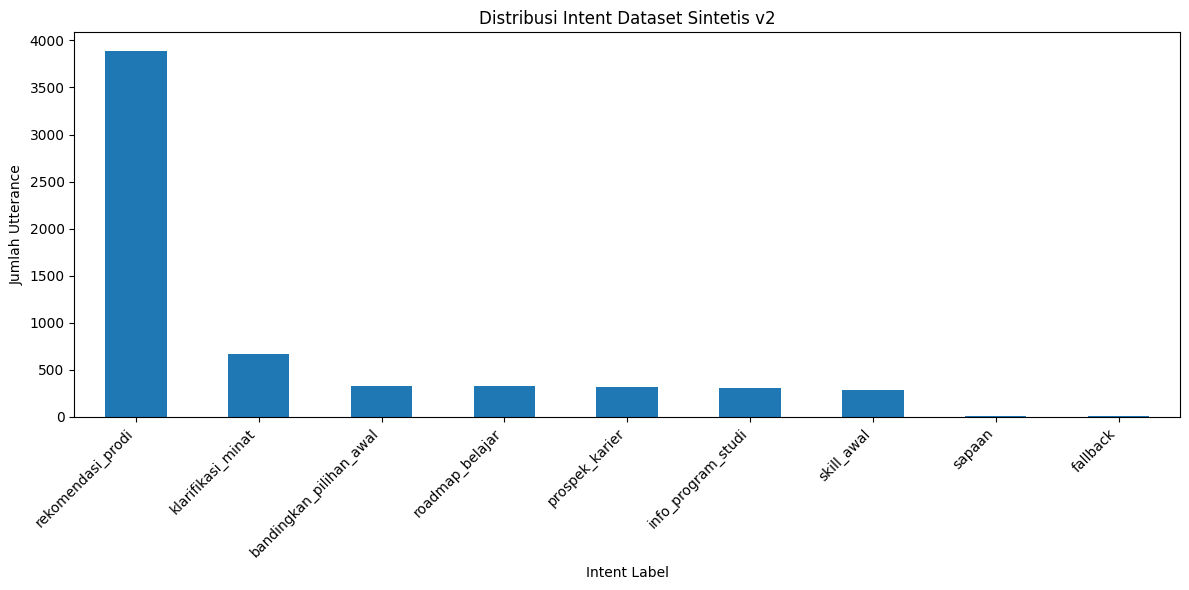

Saved: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\figures\stage10\intent_label_distribution_stage10.png


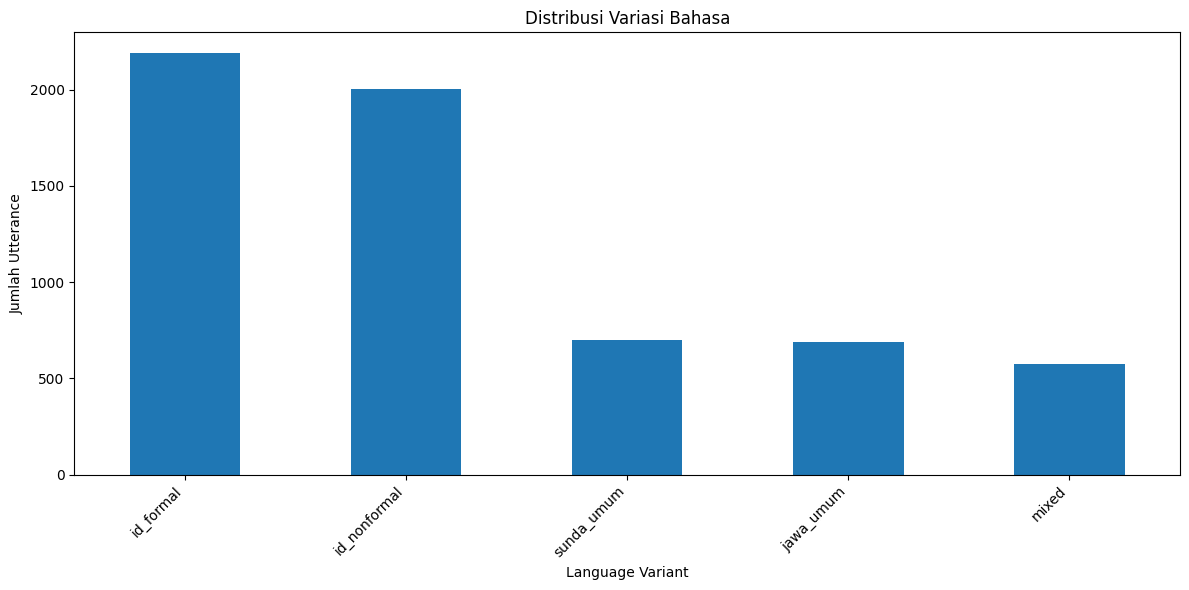

Saved: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\figures\stage10\language_variant_distribution_stage10.png


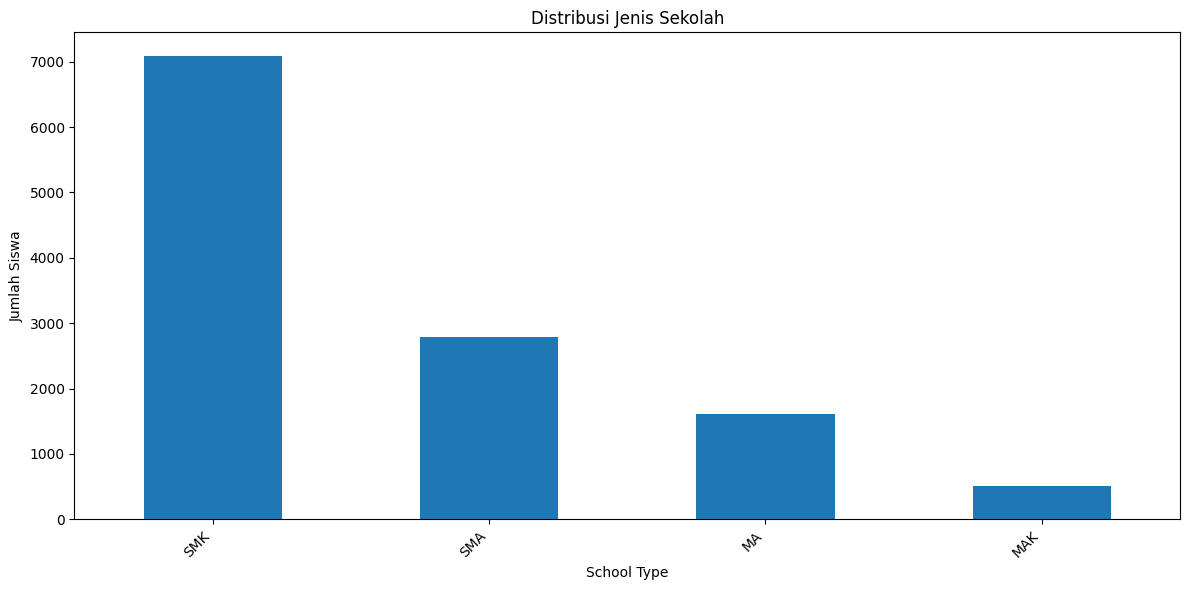

Saved: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\figures\stage10\school_type_distribution_stage10.png


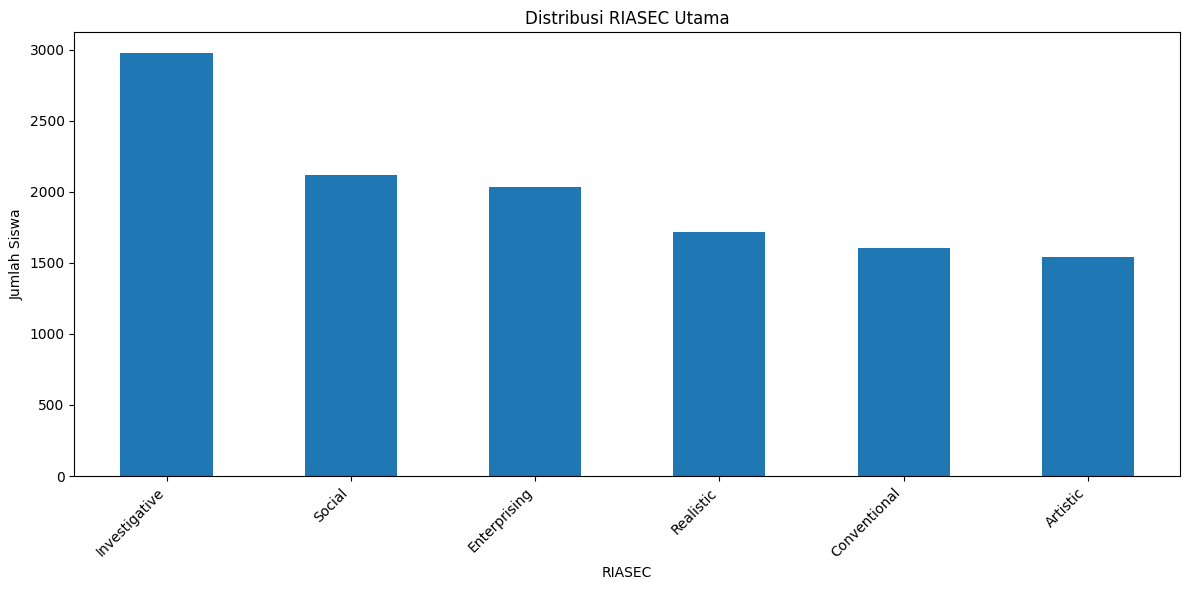

Saved: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\figures\stage10\riasec_distribution_stage10.png


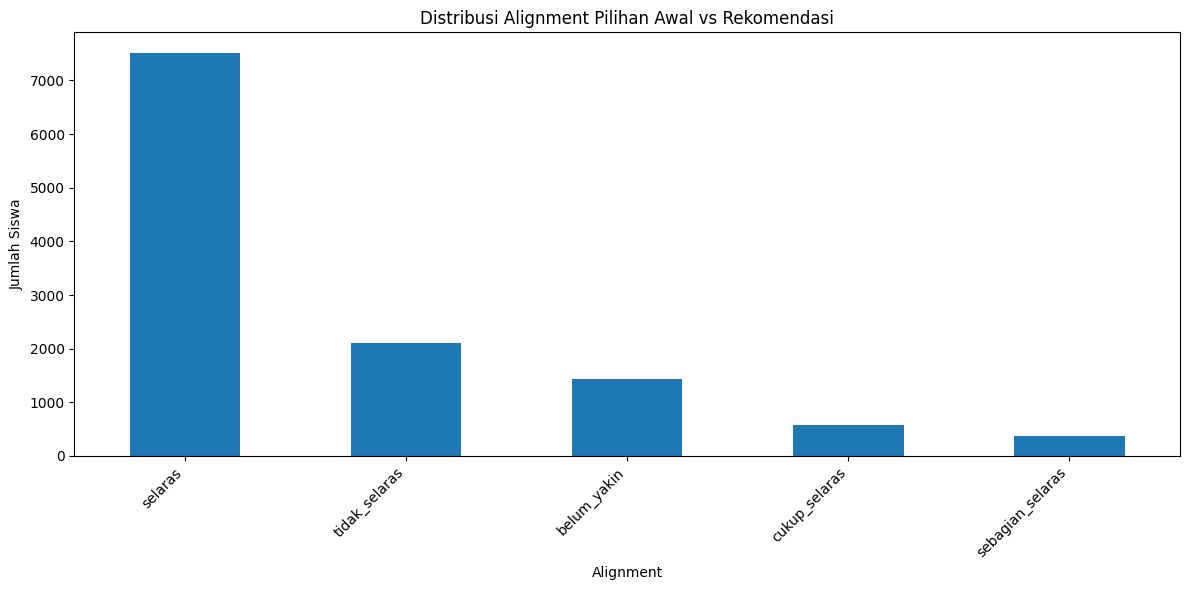

Saved: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\figures\stage10\initial_choice_alignment_distribution_stage10.png


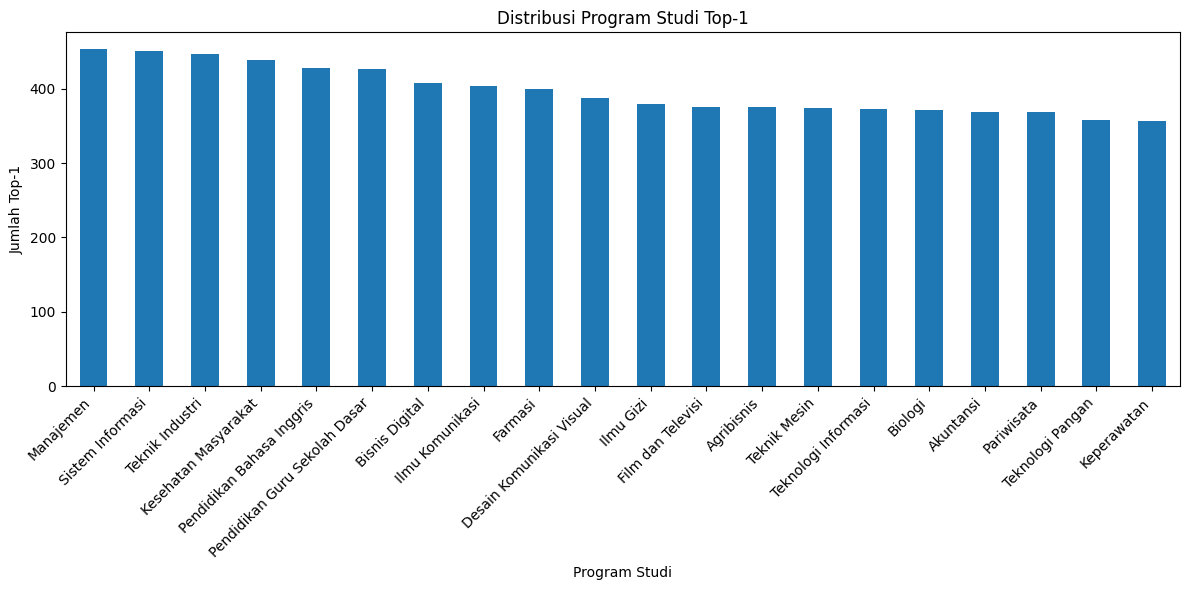

Saved: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\figures\stage10\top1_program_distribution_stage10.png


In [10]:
def save_bar_plot(series: pd.Series, title: str, xlabel: str, ylabel: str, filename: str, top_n: int = 20):
    plot_series = series.head(top_n)
    plt.figure(figsize=(12, 6))
    plot_series.plot(kind="bar")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    output_path = FIGURE_STAGE10_DIR / filename
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)

save_bar_plot(intent_dataset_df["intent_label"].value_counts(), "Distribusi Intent Dataset Sintetis v2", "Intent Label", "Jumlah Utterance", "intent_label_distribution_stage10.png")
save_bar_plot(intent_dataset_df["language_variant"].value_counts(), "Distribusi Variasi Bahasa", "Language Variant", "Jumlah Utterance", "language_variant_distribution_stage10.png")
save_bar_plot(student_profiles_df["school_type"].value_counts(), "Distribusi Jenis Sekolah", "School Type", "Jumlah Siswa", "school_type_distribution_stage10.png")
save_bar_plot(student_profiles_df["riasec_primary"].value_counts(), "Distribusi RIASEC Utama", "RIASEC", "Jumlah Siswa", "riasec_distribution_stage10.png")
save_bar_plot(initial_vs_recommendation_df["alignment_status"].value_counts(), "Distribusi Alignment Pilihan Awal vs Rekomendasi", "Alignment", "Jumlah Siswa", "initial_choice_alignment_distribution_stage10.png")
save_bar_plot(profile_mapping_df[profile_mapping_df["recommendation_rank"].eq(1)]["program_name"].value_counts(), "Distribusi Program Studi Top-1", "Program Studi", "Jumlah Top-1", "top1_program_distribution_stage10.png")

**Interpretasi:**  
Jika ada label atau program studi yang terlalu dominan, hal tersebut perlu dicatat sebagai potensi bias generator dan dapat dikalibrasi pada iterasi berikutnya.


## 12. Export Dataset ke CSV

Cell berikut menyimpan seluruh dataset dan laporan Tahap 10.


In [11]:
output_files = {
    "student_profiles": SYNTHETIC_DIR / "student_profiles_synthetic_v2.csv",
    "chat_history": SYNTHETIC_DIR / "chat_history_synthetic_v2.csv",
    "intent_dataset": SYNTHETIC_DIR / "intent_dataset_synthetic_v2.csv",
    "intent_dataset_processed_copy": PROCESSED_DIR / "intent_dataset_v2_synthetic.csv",
    "profile_mapping": SYNTHETIC_DIR / "profile_mapping_synthetic_v2.csv",
    "initial_vs_recommendation": SYNTHETIC_DIR / "initial_major_vs_recommendation_v2.csv",
    "quality_report": REPORT_STAGE10_DIR / "synthetic_data_quality_report_stage10.csv",
}

student_profiles_df.to_csv(output_files["student_profiles"], index=False, encoding="utf-8-sig")
chat_history_df.to_csv(output_files["chat_history"], index=False, encoding="utf-8-sig")
intent_dataset_df.to_csv(output_files["intent_dataset"], index=False, encoding="utf-8-sig")
intent_dataset_df.to_csv(output_files["intent_dataset_processed_copy"], index=False, encoding="utf-8-sig")
profile_mapping_df.to_csv(output_files["profile_mapping"], index=False, encoding="utf-8-sig")
initial_vs_recommendation_df.to_csv(output_files["initial_vs_recommendation"], index=False, encoding="utf-8-sig")
quality_report_df.to_csv(output_files["quality_report"], index=False, encoding="utf-8-sig")

export_summary_df = pd.DataFrame([
    {
        "output_name": name,
        "output_path": str(path.relative_to(PROJECT_ROOT)) if path.exists() else str(path),
        "exists": path.exists(),
        "size_bytes": path.stat().st_size if path.exists() else 0,
    }
    for name, path in output_files.items()
])

export_summary_path = REPORT_STAGE10_DIR / "stage10_output_checklist.csv"
export_summary_df.to_csv(export_summary_path, index=False, encoding="utf-8-sig")

display(export_summary_df)
print("Checklist saved:", export_summary_path)

,output_name,output_path,exists,size_bytes
0,student_profiles,data\synthetic\student_profiles_synthetic_v2.csv,True,8670646
1,chat_history,data\synthetic\chat_history_synthetic_v2.csv,True,10802596
2,intent_dataset,data\synthetic\intent_dataset_synthetic_v2.csv,True,2135377
3,intent_dataset_processed_copy,data\processed\intent_dataset_v2_synthetic.csv,True,2135377
4,profile_mapping,data\synthetic\profile_mapping_synthetic_v2.csv,True,16592056
5,initial_vs_recommendation,data\synthetic\initial_major_vs_recommendation...,True,4153979
6,quality_report,reports\stage10\synthetic_data_quality_report_...,True,1577


Checklist saved: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\stage10\stage10_output_checklist.csv


**Interpretasi:**  
File paling penting untuk tahap berikutnya adalah `intent_dataset_v2_synthetic.csv`, `student_profiles_synthetic_v2.csv`, dan `profile_mapping_synthetic_v2.csv`.


## 13. Kesimpulan Akademik untuk Laporan UAS

Cell ini membuat ringkasan statistik dan kesimpulan akademik otomatis dalam format Markdown.


In [12]:
summary_rows = [
    {"metric": "Jumlah profil siswa sintetis", "value": len(student_profiles_df)},
    {"metric": "Jumlah chat history rows", "value": len(chat_history_df)},
    {"metric": "Jumlah conversation sintetis", "value": chat_history_df["conversation_id"].nunique()},
    {"metric": "Jumlah utterance intent dataset", "value": len(intent_dataset_df)},
    {"metric": "Jumlah label intent", "value": intent_dataset_df["intent_label"].nunique()},
    {"metric": "Jumlah variasi bahasa", "value": intent_dataset_df["language_variant"].nunique()},
    {"metric": "Jumlah profile mapping rows", "value": len(profile_mapping_df)},
    {"metric": "Jumlah program studi tercakup di rekomendasi", "value": profile_mapping_df["program_id"].nunique()},
    {"metric": "Rata-rata skor Top-1", "value": round(profile_mapping_df[profile_mapping_df["recommendation_rank"].eq(1)]["final_score"].mean(), 3)},
    {"metric": "Jumlah kategori alignment", "value": initial_vs_recommendation_df["alignment_status"].nunique()},
]

stage10_summary_df = pd.DataFrame(summary_rows)
stage10_summary_path = REPORT_STAGE10_DIR / "stage10_synthetic_dataset_summary.csv"
stage10_summary_df.to_csv(stage10_summary_path, index=False, encoding="utf-8-sig")
display(stage10_summary_df)

intent_top = intent_dataset_df["intent_label"].value_counts().head(3)
riasec_top = student_profiles_df["riasec_primary"].value_counts().head(3)
alignment_top = initial_vs_recommendation_df["alignment_status"].value_counts()

conclusion_md = f"""
# Kesimpulan Tahap 10 — Synthetic Dataset Generator for EduPath v2

Tahap 10 berhasil membangun synthetic dataset generator untuk mendukung pengembangan EduPath Career Assistant v2. Generator memanfaatkan taxonomy hasil Tahap 09, meliputi taxonomy sekolah Indonesia, program studi PDDikti-style, RIASEC, Multiple Intelligences, VARK, Grit/Mindset, dan Career Alignment.

Output utama yang dihasilkan adalah:

1. Student Profiles Synthetic v2 sebanyak {len(student_profiles_df):,} baris.
2. Chat History Synthetic v2 sebanyak {len(chat_history_df):,} baris dari {chat_history_df['conversation_id'].nunique():,} conversation.
3. Intent Dataset Synthetic v2 sebanyak {len(intent_dataset_df):,} utterance dengan {intent_dataset_df['intent_label'].nunique()} label intent.
4. Profile Mapping Synthetic v2 sebanyak {len(profile_mapping_df):,} baris untuk pemetaan Top-{TOP_N_RECOMMENDATION} program studi.
5. Initial Major vs Recommendation v2 sebanyak {len(initial_vs_recommendation_df):,} baris untuk membandingkan pilihan awal siswa dengan rekomendasi sistem.

Intent yang paling banyak muncul:

{intent_top.to_string()}

RIASEC utama yang dominan:

{riasec_top.to_string()}

Distribusi alignment pilihan awal vs rekomendasi:

{alignment_top.to_string()}

Secara akademik, dataset sintetis ini layak digunakan sebagai data awal untuk eksperimen Data Mining, khususnya intent classification, taxonomy mapping, dan hybrid recommender system. Namun, dataset ini tetap memiliki keterbatasan karena dibangun dari aturan sintetis, bukan data empiris siswa nyata. Oleh karena itu, pada pengembangan berikutnya diperlukan validasi domain expert, pengujian bias distribusi, dan kalibrasi scoring engine.

Catatan etis: seluruh data pada tahap ini adalah sintetis dan tidak merepresentasikan identitas siswa sebenarnya. Rekomendasi EduPath bersifat bantuan awal, bukan keputusan final pemilihan program studi.
""".strip()

conclusion_path = REPORT_STAGE10_DIR / "stage10_academic_conclusion.md"
with open(conclusion_path, "w", encoding="utf-8") as f:
    f.write(conclusion_md)

print(conclusion_md)
print("\nSummary saved:", stage10_summary_path)
print("Conclusion saved:", conclusion_path)

,metric,value
0,Jumlah profil siswa sintetis,12000.00
1,Jumlah chat history rows,64000.00
2,Jumlah conversation sintetis,8000.00
3,Jumlah utterance intent dataset,6151.00
4,Jumlah label intent,9.00
5,Jumlah variasi bahasa,5.00
6,Jumlah profile mapping rows,60000.00
7,Jumlah program studi tercakup di rekomendasi,35.00
8,Rata-rata skor Top-1,0.88
9,Jumlah kategori alignment,5.00


# Kesimpulan Tahap 10 — Synthetic Dataset Generator for EduPath v2

Tahap 10 berhasil membangun synthetic dataset generator untuk mendukung pengembangan EduPath Career Assistant v2. Generator memanfaatkan taxonomy hasil Tahap 09, meliputi taxonomy sekolah Indonesia, program studi PDDikti-style, RIASEC, Multiple Intelligences, VARK, Grit/Mindset, dan Career Alignment.

Output utama yang dihasilkan adalah:

1. Student Profiles Synthetic v2 sebanyak 12,000 baris.
2. Chat History Synthetic v2 sebanyak 64,000 baris dari 8,000 conversation.
3. Intent Dataset Synthetic v2 sebanyak 6,151 utterance dengan 9 label intent.
4. Profile Mapping Synthetic v2 sebanyak 60,000 baris untuk pemetaan Top-5 program studi.
5. Initial Major vs Recommendation v2 sebanyak 12,000 baris untuk membandingkan pilihan awal siswa dengan rekomendasi sistem.

Intent yang paling banyak muncul:

intent_label
rekomendasi_prodi          3891
klarifikasi_minat           670
bandingkan_pilihan_awal     332

RIASEC utama yang 

## 14. Checklist File Output untuk Tahap Berikutnya

Checklist ini memastikan semua file penting Tahap 10 tersedia sebelum lanjut ke Tahap 11.


In [14]:
expected_next_stage_files = [
    SYNTHETIC_DIR / "student_profiles_synthetic_v2.csv",
    SYNTHETIC_DIR / "chat_history_synthetic_v2.csv",
    SYNTHETIC_DIR / "intent_dataset_synthetic_v2.csv",
    PROCESSED_DIR / "intent_dataset_v2_synthetic.csv",
    SYNTHETIC_DIR / "profile_mapping_synthetic_v2.csv",
    SYNTHETIC_DIR / "initial_major_vs_recommendation_v2.csv",
    REPORT_STAGE10_DIR / "synthetic_data_quality_report_stage10.csv",
    REPORT_STAGE10_DIR / "stage10_output_checklist.csv",
    REPORT_STAGE10_DIR / "stage10_synthetic_dataset_summary.csv",
    REPORT_STAGE10_DIR / "stage10_academic_conclusion.md",
    FIGURE_STAGE10_DIR / "intent_label_distribution_stage10.png",
    FIGURE_STAGE10_DIR / "language_variant_distribution_stage10.png",
    FIGURE_STAGE10_DIR / "school_type_distribution_stage10.png",
    FIGURE_STAGE10_DIR / "riasec_distribution_stage10.png",
    FIGURE_STAGE10_DIR / "initial_choice_alignment_distribution_stage10.png",
    FIGURE_STAGE10_DIR / "top1_program_distribution_stage10.png",
]

next_stage_checklist_df = pd.DataFrame([
    {
        "file_path": str(path.relative_to(PROJECT_ROOT)) if path.exists() else str(path),
        "exists": path.exists(),
        "size_bytes": path.stat().st_size if path.exists() else 0,
        "recommended_for_stage11": True,
    }
    for path in expected_next_stage_files
])

next_stage_checklist_path = REPORT_STAGE10_DIR / "stage10_next_stage_file_checklist.csv"
next_stage_checklist_df.to_csv(next_stage_checklist_path, index=False, encoding="utf-8-sig")
display(next_stage_checklist_df)
print("Next stage checklist saved:", next_stage_checklist_path)

,file_path,exists,size_bytes,recommended_for_stage11
0,data\synthetic\student_profiles_synthetic_v2.csv,True,8670646,True
1,data\synthetic\chat_history_synthetic_v2.csv,True,10802596,True
2,data\synthetic\intent_dataset_synthetic_v2.csv,True,2135377,True
3,data\processed\intent_dataset_v2_synthetic.csv,True,2135377,True
4,data\synthetic\profile_mapping_synthetic_v2.csv,True,16592056,True
5,data\synthetic\initial_major_vs_recommendation...,True,4153979,True
6,reports\stage10\synthetic_data_quality_report_...,True,1577,True
7,reports\stage10\stage10_output_checklist.csv,True,623,True
8,reports\stage10\stage10_synthetic_dataset_summ...,True,364,True
9,reports\stage10\stage10_academic_conclusion.md,True,1968,True


Next stage checklist saved: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\UAS\edupath-career-assitant\reports\stage10\stage10_next_stage_file_checklist.csv
